# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm



## Dataset Overview

This dataset is derived from the National Supported Work (NSW) Demonstration, famously analyzed by Robert LaLonde (1986) and later by Dehejia and Wahba (1999) to benchmark causal inference and econometric models. The data was loaded directly from the MatchIt package repository.

DATASET CHARACTERISTICS:
* Number of Samples: 614 observations. This specific subset contains individuals who received the job training (treated) combined with a non-experimental comparison group (control).  
* Number of Features: 9 variables (including the target and treatment indicators).

STRUCTURE OF THE DATASET: 
* Target Variable: re78 (Real annual earnings in 1978, post-treatment).  
* Treatment Indicator: treat (1 if the individual received the job training intervention, 0 if they were in the control group).  
* Pre-Treatment Covariates: 7 demographic and historical earnings features used to control for confounding bias. These include age, education (educ), race (black, hisp), marital status (married), educational attainment (nodegr), and historical pre-training earnings (re74, re75).

In [4]:
# Load the data
df = sm.datasets.get_rdataset("lalonde", "MatchIt").data

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}\n")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
display(df.head())

# Show basic data types and info
print("\nDataset Info:")
display(df.info())

Number of samples: 614
Number of features: 9

Example data:


,treat,age,educ,race,married,nodegree,re74,re75,re78
rownames,,,,,,,,,
NSW1,1,37,11,black,1,1,0.0,0.0,9930.0460
NSW2,1,22,9,hispan,0,1,0.0,0.0,3595.8940
NSW3,1,30,12,black,0,0,0.0,0.0,24909.4500
NSW4,1,27,11,black,0,1,0.0,0.0,7506.1460
NSW5,1,33,8,black,0,1,0.0,0.0,289.7899



Dataset Info:
<class 'pandas.DataFrame'>
Index: 614 entries, NSW1 to PSID429
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   treat     614 non-null    int64  
 1   age       614 non-null    int64  
 2   educ      614 non-null    int64  
 3   race      614 non-null    str    
 4   married   614 non-null    int64  
 5   nodegree  614 non-null    int64  
 6   re74      614 non-null    float64
 7   re75      614 non-null    float64
 8   re78      614 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 48.0+ KB


None

## Handling Missing Values

An analysis of the dataset revealed that it is entirely complete. There are 0 missing or null values across all features and target variables, so no imputation or row-dropping was necessary


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


treat       0
age         0
educ        0
race        0
married     0
nodegree    0
re74        0
re75        0
re78        0
dtype: int64

## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


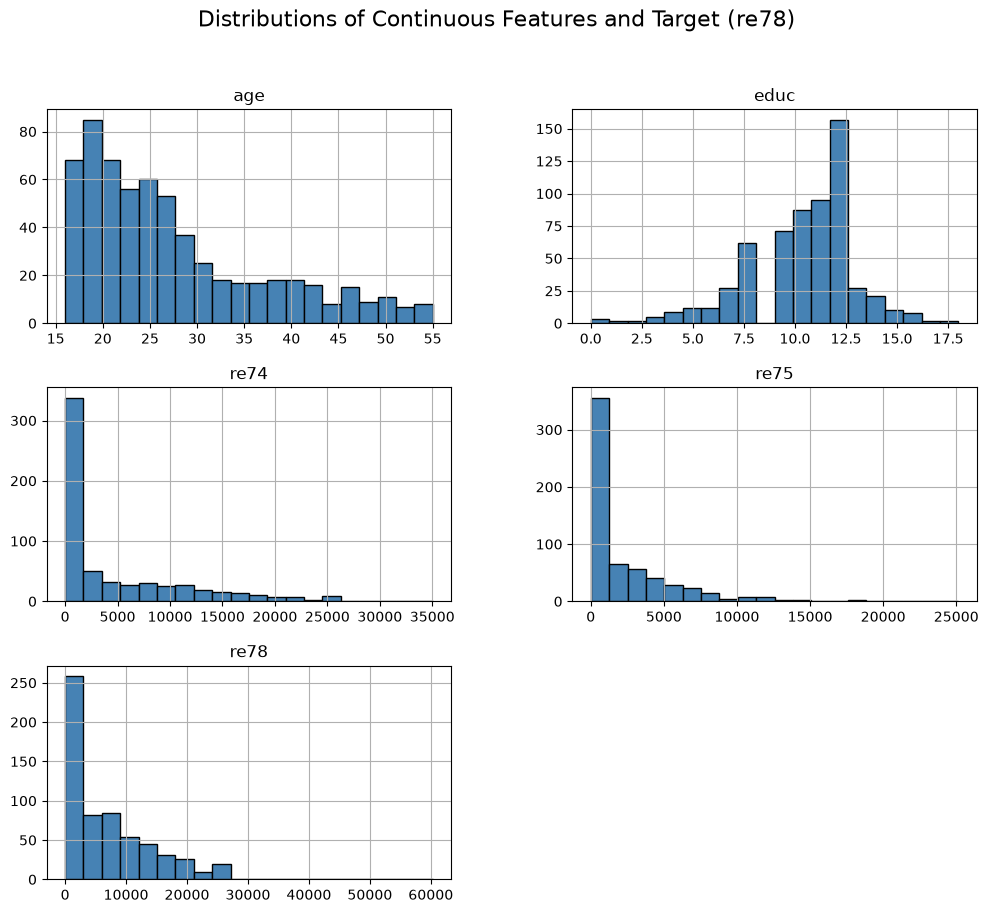

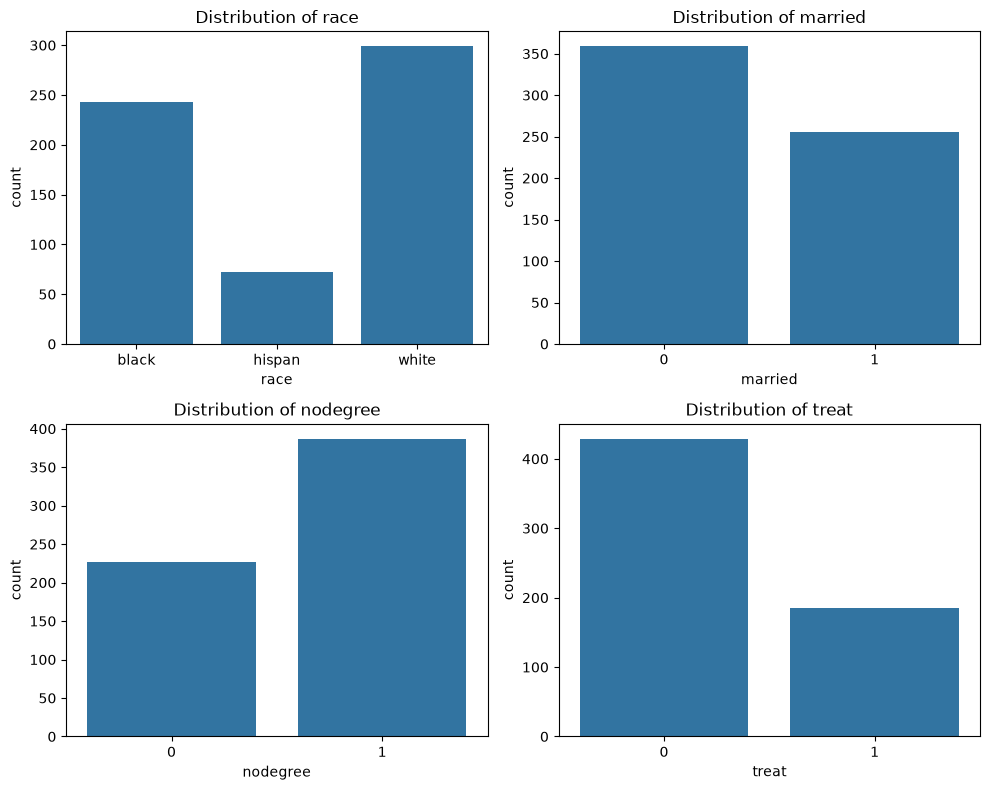

In [6]:
# Plotting histograms of continuous features and the target variable (re78)
continuous_features = ['age', 'educ', 're74', 're75', 're78']

df[continuous_features].hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distributions of Continuous Features and Target (re78)', fontsize=16)
plt.show()

# Visualizing the categorical/binary features (Updated for the MatchIt column names!)
categorical_features = ['race', 'married', 'nodegree', 'treat']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, feature in enumerate(categorical_features):
    sns.countplot(
        ax=axes[i//2, i%2],
        x=feature,
        data=df,
    )
    axes[i//2, i%2].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()


## Possible Biases

An investigation of the treatment and control groups reveals significant biases and imbalances in the dataset. Because this subset combines the experimental treated group with a non-experimental control group, the two populations are fundamentally different across almost all features.

1. Class Imbalance (Treatment vs. Control)

* Imbalance: There is a moderate class imbalance in the treatment assignment. The control group makes up roughly 70% (429 individuals) of the dataset, while the treated group makes up only 30% (185 individuals).

2. Selection Bias and Confounding Variables
A naive comparison between the treated and control groups would be highly inaccurate because the baseline characteristics of the two groups are extremely skewed. Key imbalances include:

* Historical Earnings: The control group was already making significantly more money before the training program began. In 1974, the control group earned an average of $5,619, compared to just $2,095 for the treated group.

* Racial and Ethnic Disparities: The racial makeup of the two groups is completely inverted. The treated group is predominantly Black (84.3%), while the control group is predominantly White (65.5%).

* Marital Status: Individuals in the control group are highly likely to be married (51.3%), whereas very few in the treated group are married (18.9%).

* Educational Attainment: A higher percentage of the treated group lacks a high school degree (70.8%) compared to the control group (59.7%).

Conclusion & Implications for Modeling:
The data shows heavy selection bias. The treated group is generally younger, less likely to be married, more likely to be a minority, and possessed significantly lower historical earning power than the control group.

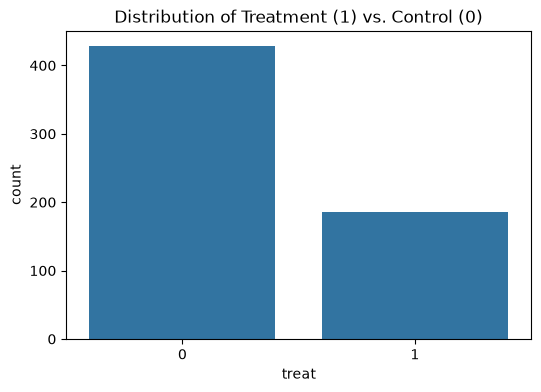

Treatment Value Counts:
treat
0    429
1    185
Name: count, dtype: int64

Treatment Proportions:
treat
0    0.699
1    0.301
Name: proportion, dtype: float64

Mean of numerical covariates by treatment group:


treat,0,1
age,28.030303,25.816216
educ,10.235431,10.345946
married,0.512821,0.189189
nodegree,0.596737,0.708108
re74,5619.236506,2095.573689
re75,2466.484443,1532.055314
re78,6984.169742,6349.143530



Race distribution by treatment group (Proportions):


race,black,hispan,white
treat,,,
0,0.203,0.142,0.655
1,0.843,0.059,0.097


In [7]:
# 1. Checking for class imbalance in the treatment assignment
plt.figure(figsize=(6, 4))
sns.countplot(x='treat', data=df)
plt.title('Distribution of Treatment (1) vs. Control (0)')
plt.show()

print("Treatment Value Counts:")
print(df['treat'].value_counts())
print("\nTreatment Proportions:")
print(df['treat'].value_counts(normalize=True).round(3))

# 2. Checking covariate balance (bias between treatment and control groups)
# This shows if the treated and control groups look similar prior to the intervention.
# We use numeric_only=True to safely calculate means for numeric columns only.
covariate_balance = df.groupby('treat').mean(numeric_only=True).T
print("\nMean of numerical covariates by treatment group:")
display(covariate_balance)

# 3. Checking categorical balance (e.g., race) across treatment groups
if 'race' in df.columns:
    print("\nRace distribution by treatment group (Proportions):")
    race_balance = pd.crosstab(df['treat'], df['race'], normalize='index').round(3)
    display(race_balance)

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


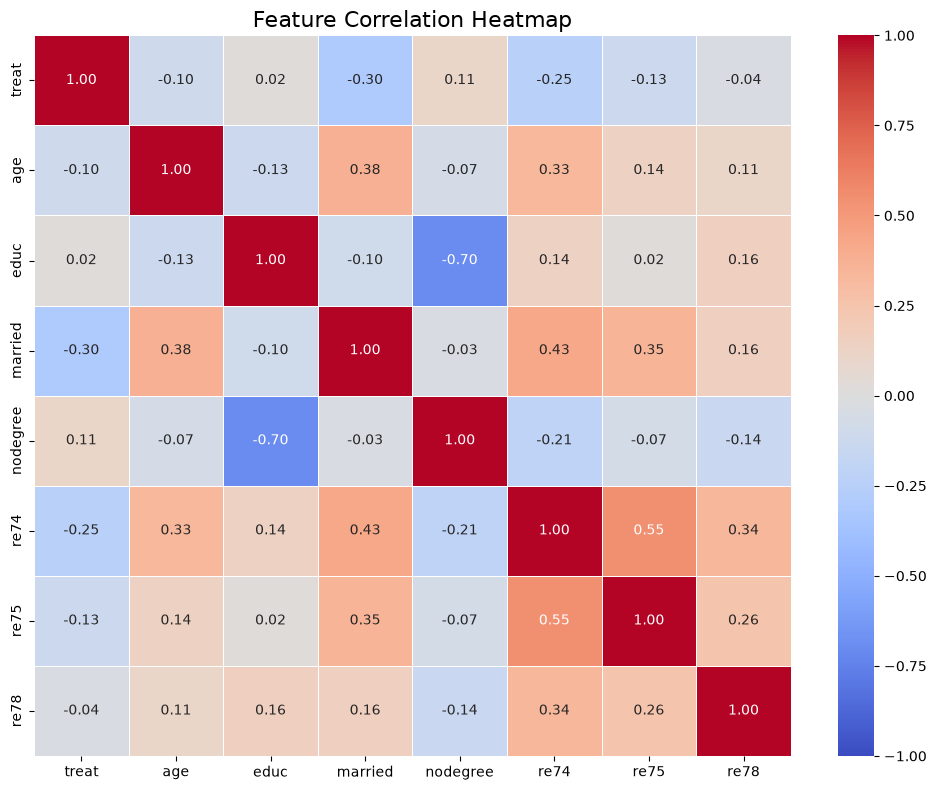

In [8]:
# Plotting a heatmap to show feature correlations
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix (ignoring the categorical 'race' column)
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, 
            annot=True,          # Shows the exact correlation numbers in the boxes
            cmap='coolwarm',     # Blue for negative correlation, Red for positive
            fmt='.2f',           # Formats the numbers to 2 decimal places
            linewidths=0.5,      # Adds a small grid line between boxes
            vmin=-1, vmax=1)     # Sets the scale from -1 to 1

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()